1.	Implement Otsu thresholding (without library function). Use the local thresholding library on the Sudoku.jpeg image to show improvement over Otsu. Show the Fourier transform of the results. Show the histograms.



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

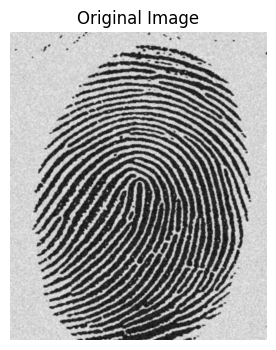

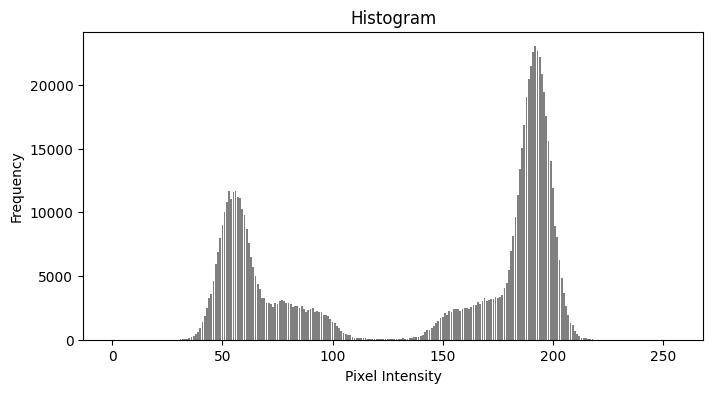

In [19]:
img=cv2.imread('E:\\BG\\fingerprint.tif',0)
rows,cols=img.shape
total_pixels=rows*cols
hist=np.zeros(256,dtype=np.int32)
for i in range(rows):
    for j in range(cols):
        hist[img[i,j]]+=1
prob=hist/total_pixels
plt.figure(figsize=(8,4))        
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.figure(figsize=(8,4))
plt.bar(range(256),hist,color='gray')
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In [20]:
max_variance=0
threshold=0
for i in range(256):
    w0=np.sum(prob[:i])
    w1=np.sum(prob[i:])
    if w0==0 or w1==0:
        continue
    mean0=np.sum(np.arange(i)*prob[:i])/w0
    mean1=np.sum(np.arange(i,256)*prob[i:])/w1
    variance=w0*w1*(mean0-mean1)**2
    if variance>max_variance:
        max_variance=variance
        threshold=i
print(f"Otsu threshold: {threshold}")


Otsu threshold: 126


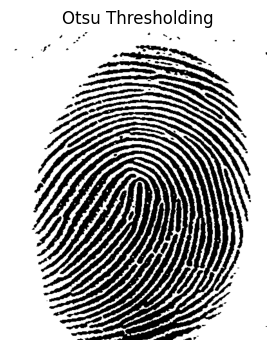

In [21]:
thres=np.zeros(img.shape,dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        if img[i,j]>threshold:
            thres[i,j]=255
        else:
            thres[i,j]=0
plt.figure(figsize=(8,4))
plt.imshow(thres,cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')
plt.show()

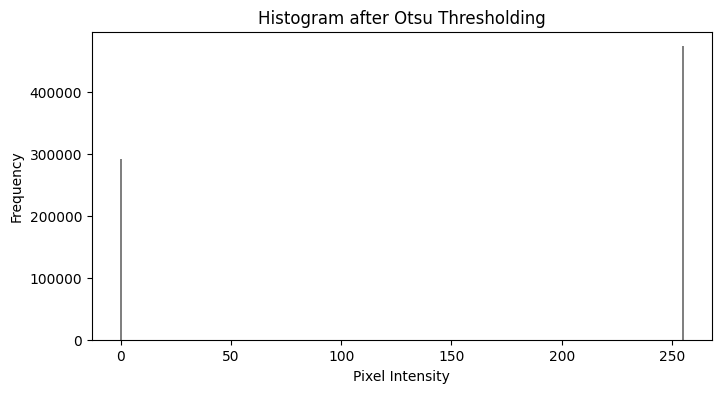

In [22]:
hist1=np.zeros(256,dtype=np.int32)
for i in range(rows):
    for j in range(cols):
        hist1[thres[i,j]]+=1
plt.figure(figsize=(8,4))
plt.bar(range(256),hist1,color='gray')
plt.title('Histogram after Otsu Thresholding')
plt.xlabel('Pixel Intensity')   
plt.ylabel('Frequency')
plt.show()